# Mastering Thresholding and Image Segmentation

In this blog, we go over the most advanced techniques yet covered in this series. From simple thresholding to the watershed algorithm, we will cover all sorts of image segmenting techniques that have numerous applications in a variety of different fields.

In [1]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

###Imports & Sample Images###

In [1]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

In [2]:
# Collecting the sample image
image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_4/Parrot_on_snowmobile.png"
resp = urllib.request.urlopen(image_url)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)

image_url_watershed = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_4/Parrots_watershed.png"
resp = urllib.request.urlopen(image_url_watershed)
image_bytes_watershed = np.asarray(bytearray(resp.read()), dtype=np.uint8)

image_url_ccl = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_4/Parrot_simple.png"
resp = urllib.request.urlopen(image_url_ccl)
image_bytes_ccl = np.asarray(bytearray(resp.read()), dtype=np.uint8)

###Utils###

In [3]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

## List of Techniques

* Simple Thresholding
* Image Binarization
* Adaptive Thresholding
* Otsu's Binarization
* Grabcut Algorithm
* Watershed Algorithm
* Connected Components Labeling

## Use Cases

Whether it be presence sensing for 3D printers using simple thresholding, warehouse shelf label reading using adaptive thresholding, or automatic pill counters using otsu's binarization, each of the image segmentation techniques we will cover in this blog have a variety of different use cases that are quite common.

## Techniques

### Simple Thresholding

**What it does:** Simple thresholding alters the target image by taking a user-inputted threshold and evaluating every pixel on the image by that value. If the evaluated pixel is less than the threshold, it will be set to 0, and if greater than, it will be set to the maximum intensity.

**Why it matters:** Simple thresholding allows users to isolate objects in images & videos, do basic edge detection, simplify images for more efficient processing, and as we have already seen in a previous blog, it is quite useful for the creation of masks on images.

**The Code & Output**

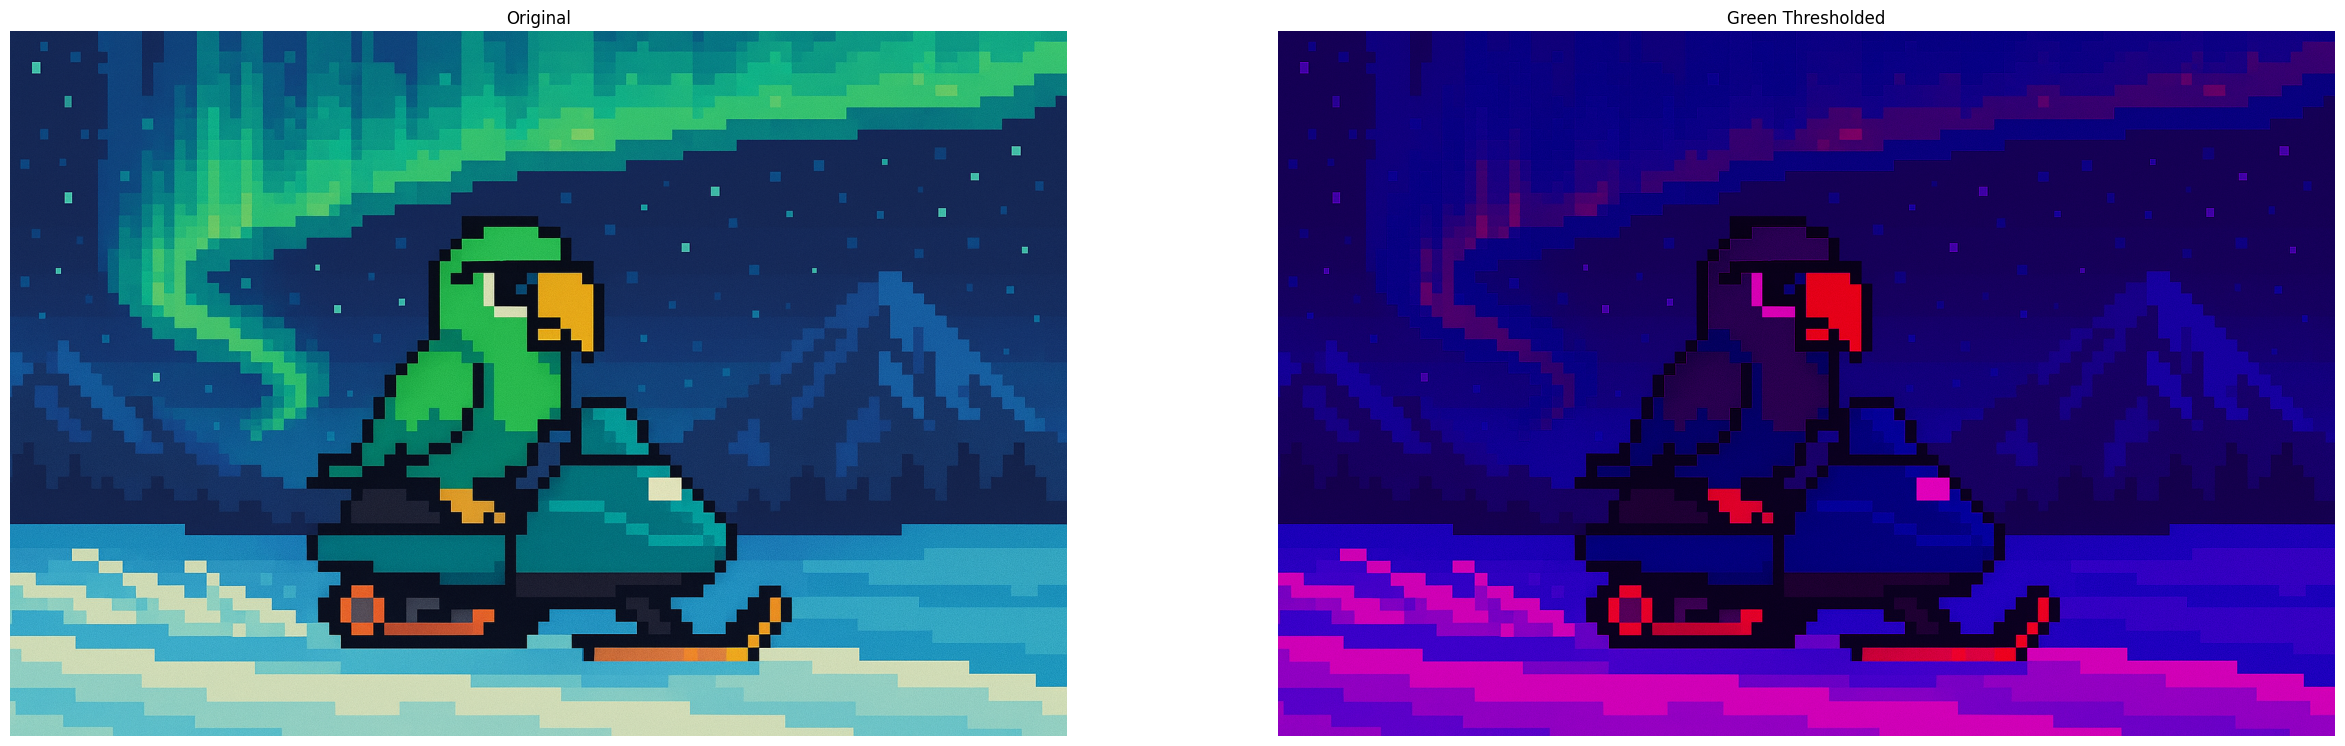

In [4]:
# Reading the sample image
bgr_image = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

# Color space conversions
image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

# Splitting the channels for thresholding an individual color
r,g,b = cv2.split(image)

# Simple Thresholding
ret, thresh_g = cv2.threshold(g, 255, 255, cv2.THRESH_BINARY)

green_thresholded = cv2.merge([r,thresh_g,b])

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, [image, green_thresholded], ["Original", "Green Thresholded"])

### Image Binarization

**What it does:** Image binarization is a technique by which a given image is converted from its original coloration to a binary intensity set based upon a given threshold.

**Why it matters:** Image binarization has a number of differetn applications, but two of the most common would be in feature & edge detection, as well as in the reduction of data sizes, so that training and image consumption of a given model that is being trained is much, much faster, as the evaluation of the image is only happening on one channel, rather than on three or more.

**The Code & Output**

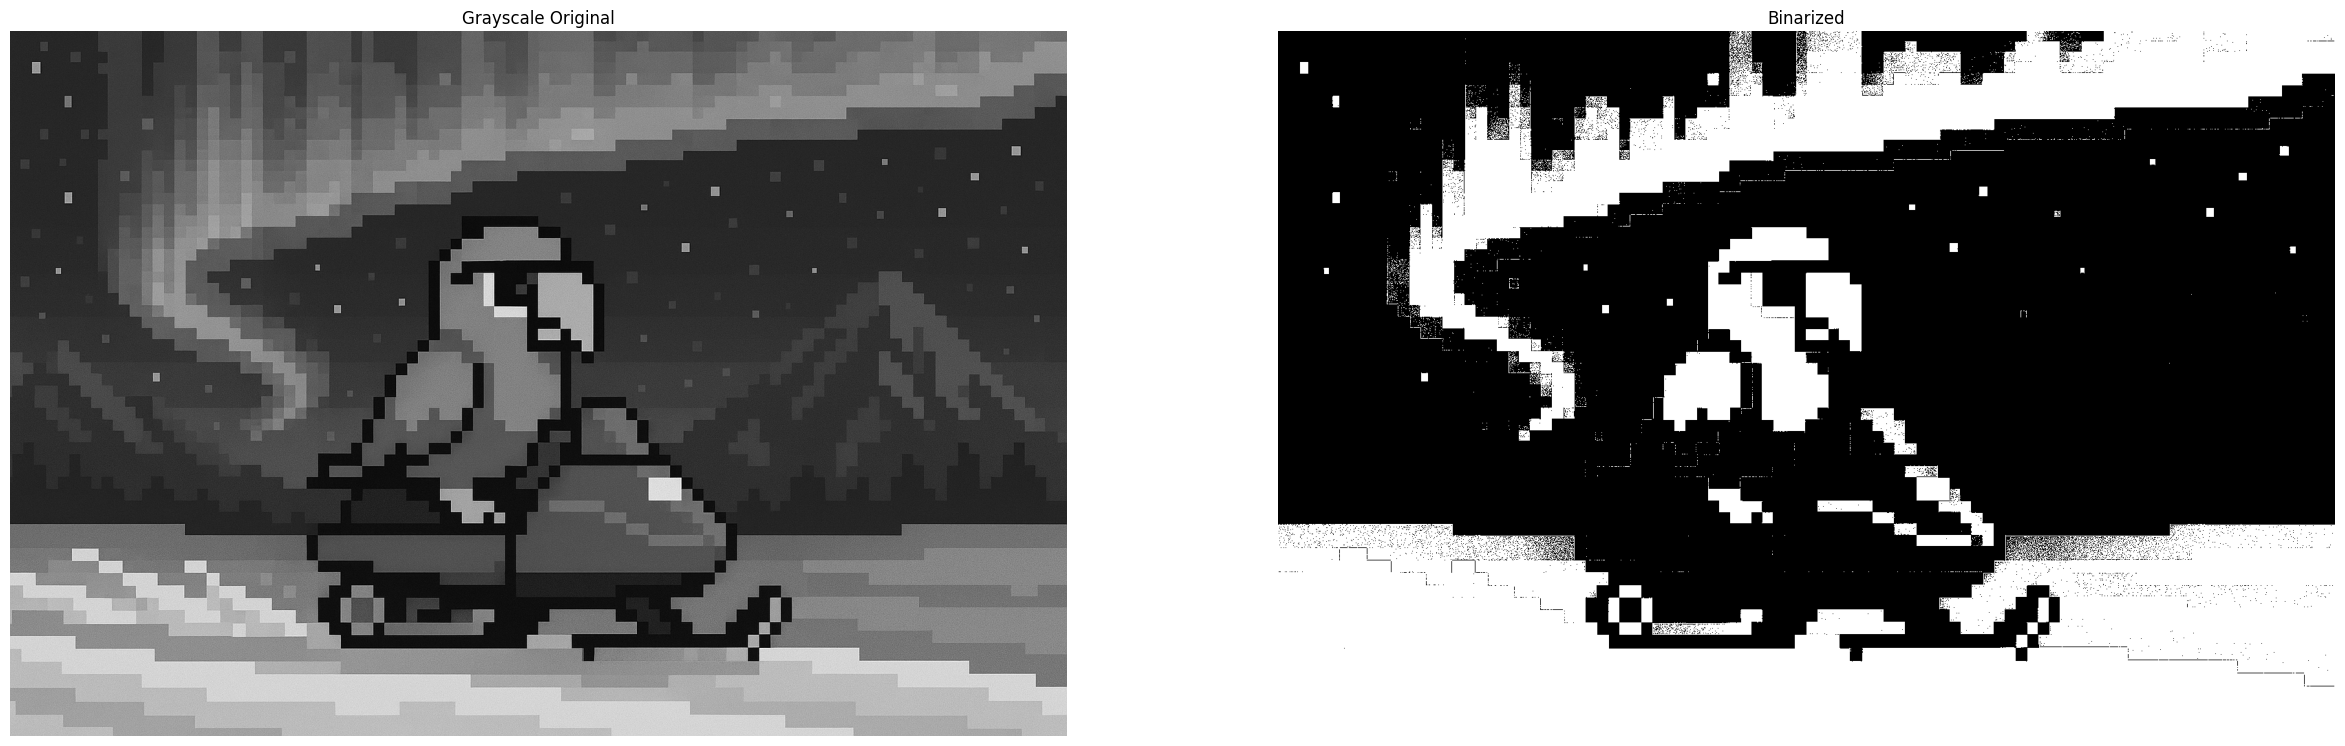

In [6]:
# Reading the sample image
image = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

# Image Binarization
ret, binarized_image = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY)

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, [image, binarized_image], ["Grayscale Original", "Binarized"], "off", ["gray"])

### Adaptive Thresholding

**What it does:** Adaptive Thresholding, rather than applying a global threshold to the entire image like in simple thresholding, it applies a dynamic threshold that is dependent upon the neighborhood of a given pixel.

**Why it matters:** Adaptive thresholding is very effective for the processing of documents for instance. Where a global threshold might be able to make some of the content of the scanned document clearer in one part of the image, it may end up obscuring detail if the lighting changes at points in the image. This is a situation where a technique like adaptive thresholding shines, as it is dynamic, and can produce consistent results regardless of original pixel intensity.

**The Code & Output**

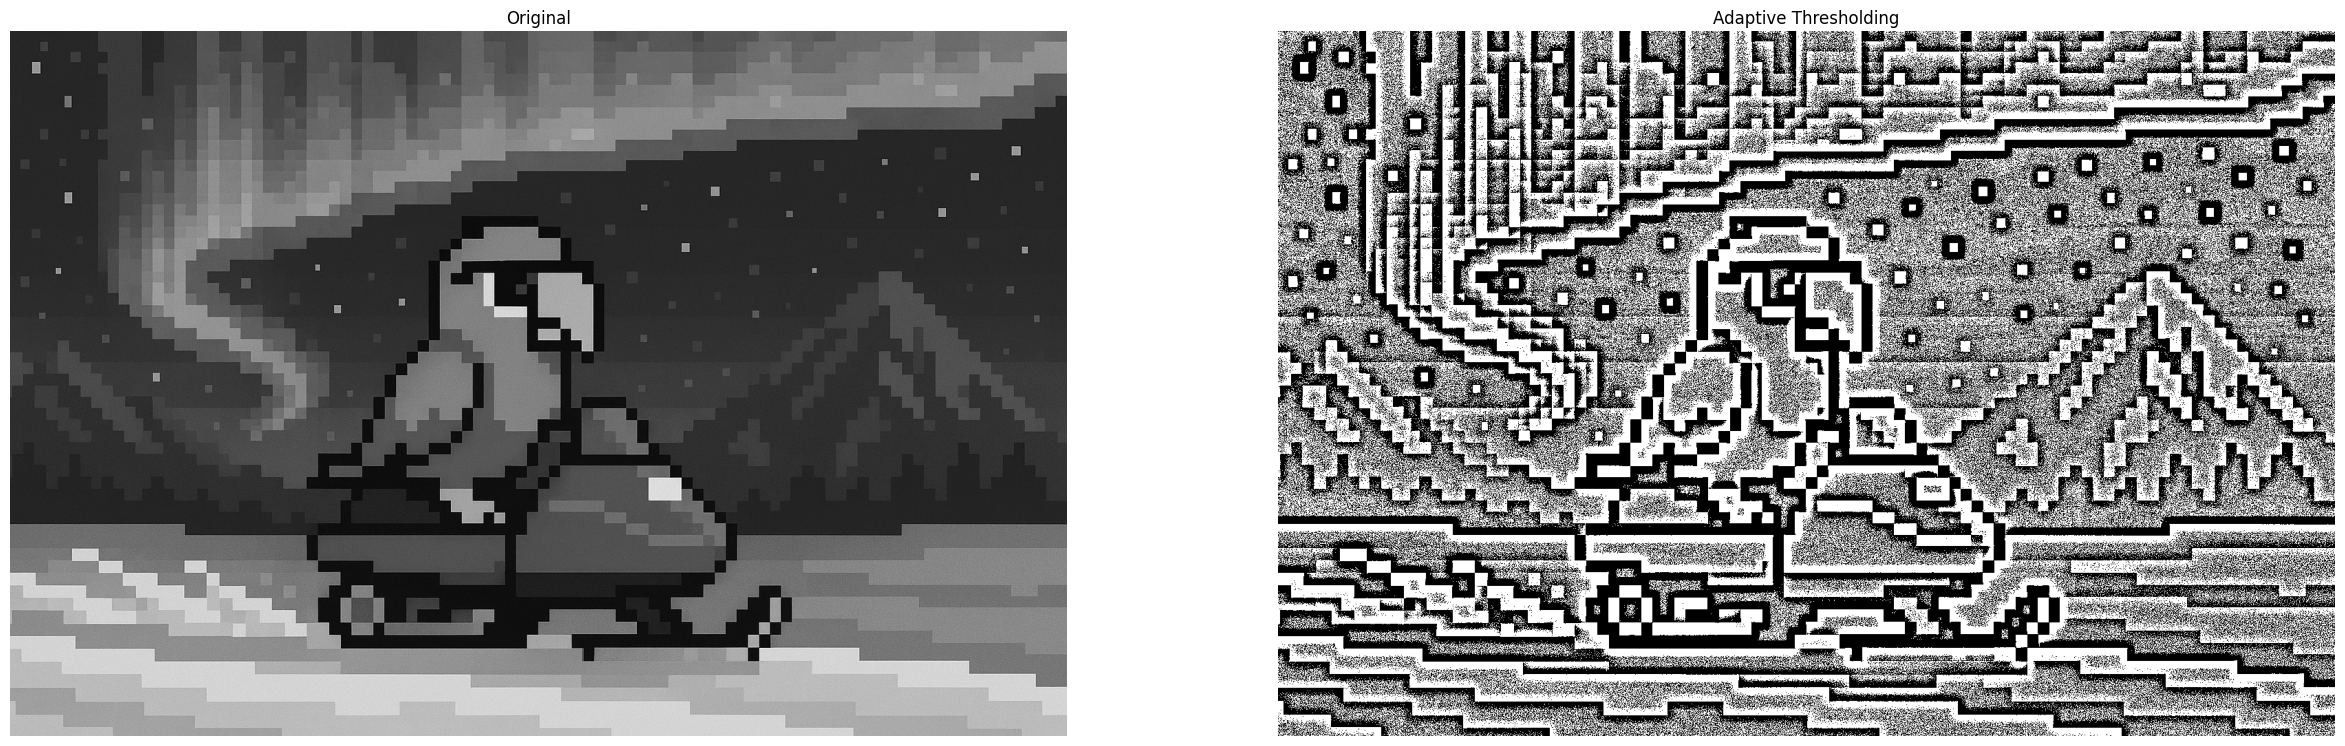

In [14]:
# Reading the sample image
image = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

# Adaptive Thresholding
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25, 1)

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, [image, thresh], ["Original", "Adaptive Thresholding"], "off", ["gray"])

### Otsu's Binarization

**What it does:** Otsu's Binarization serves a similar purpose to simple thresholding, but where in simple thresholding you must determine the threshold yourself, otsu's binarization determines the optimal threshold automatically. In this technique, the threshold passed is arbitrary, as it is overwritten automatically.

**Why it matters:** Otsu's binarization and its ability to find the optimal threshold value based upon the image's histogram is very effective for document analysis, even in some less than optimal lighting conditions. Additionally, it is often used within medical imaging, as well as license plate recognition.

**The Code & Output**

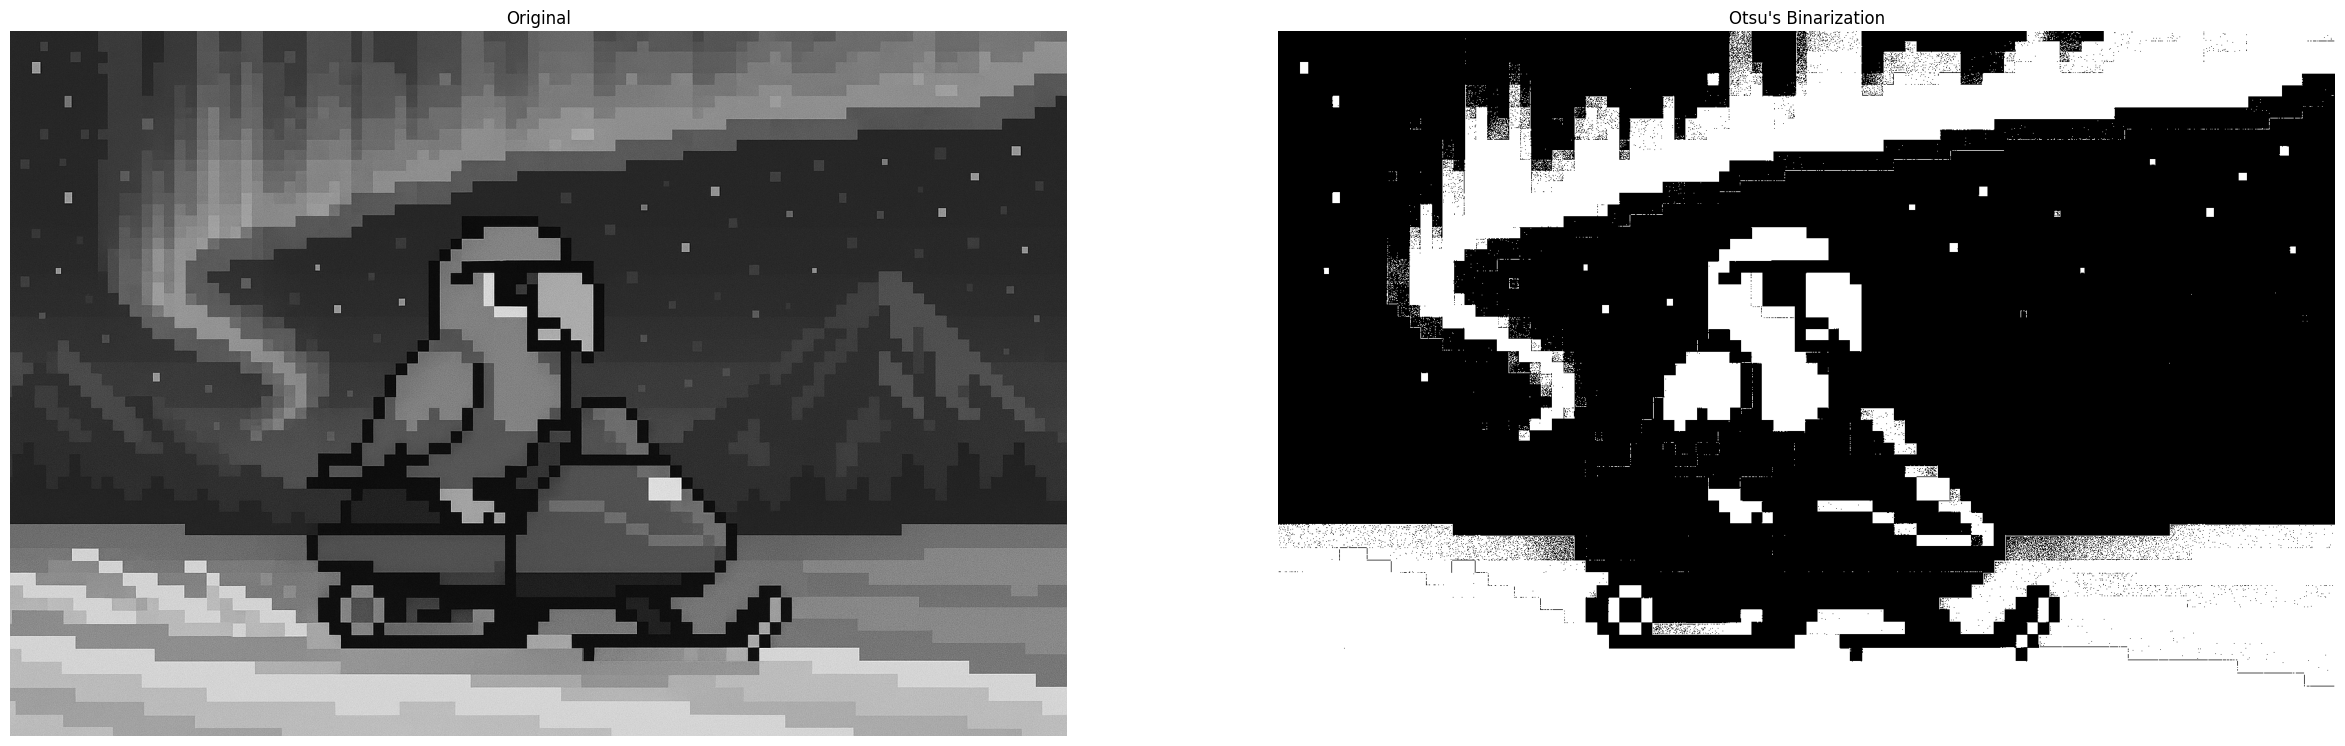

In [8]:
# Reading the sample image
image = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

# Otsu's Binarization
ret, otsu_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, [image, otsu_image], ["Original", "Otsu's Binarization"], "off", ["gray"])

### Grabcut Algorithm

**What it does:** Grabcut Algorithm is an image segmentation technique that separates the foreground from the background. It requires user interaction, typically in the form of a user drawing a rectangle around the given subject.

**Why it matters:** The Grabcut algorithm is first and foremost useful for foreground isolation from the background. It is not the fastest technique, to be sure, and while it may occasionally have artifacts surrounding your subject (as can be seen in the example), it is still a very useful technique for image segmentation.

**The Code & Output**

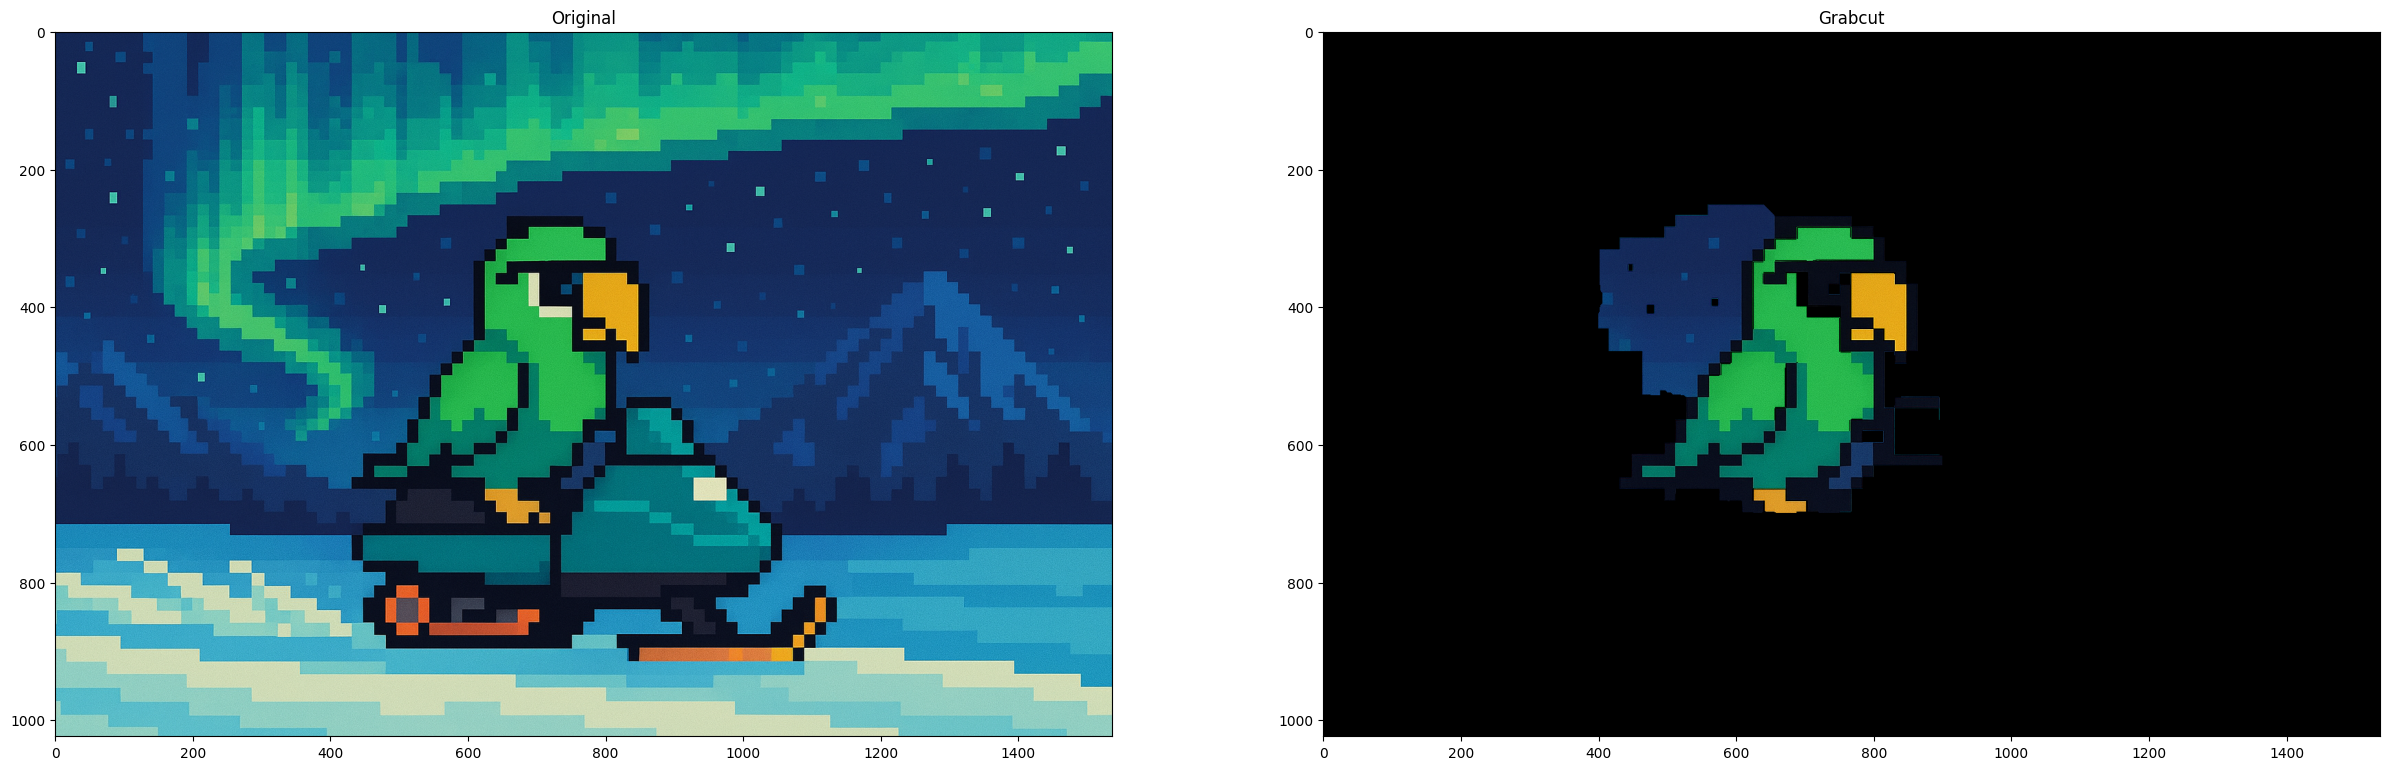

In [9]:
# Reading the sample image
bgr_image = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

# Color conversion to ensure proper display of images
image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

# Image Preprocessing
mask = np.zeros(image.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

rectangle = (400, 250, 500, 450)

# Grabcut Algorithm
cv2.grabCut(image, mask, rectangle, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask == 2)|(mask == 0), 0, 1).astype('uint8')

image_segmented = image * mask2[:, :, np.newaxis]

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, [image, image_segmented], ["Original", "Grabcut"], "on")

### Connected Components Labeling

**What it does:** Connected components labeling, as the name suggests, seeks to determine the connectivity of blobs (distinct regions within an image with regard to color or intensity) within a given image.

**Why it matters:** Connected components labeling is useful for the counting of objects within an image, the identification and tracking of those same objects, as well as in other applications such as defect detection in manufacturing.

**The Code & Output**

[INFO] examining component 1/2 (background)
[INFO] examining component 2/2


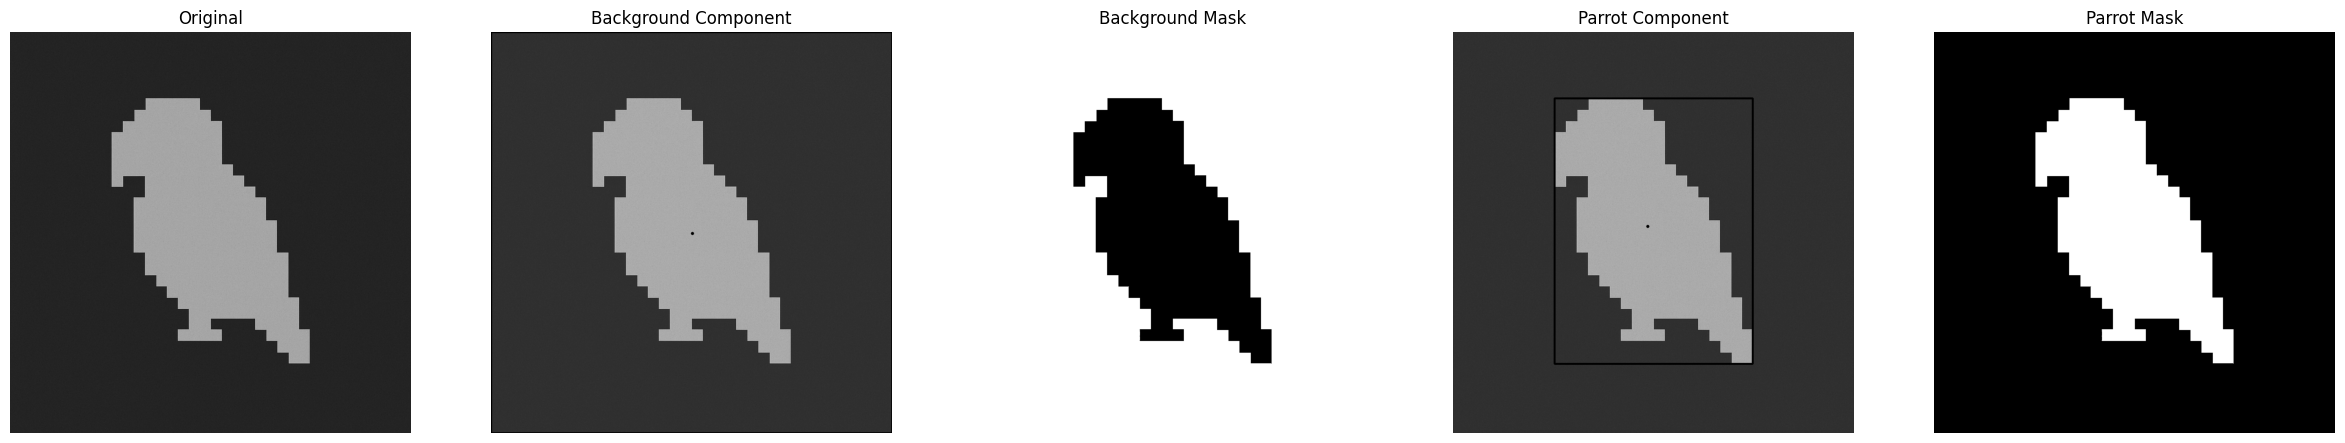

In [ ]:
# Reading the sample image
image = cv2.imdecode(image_bytes_ccl, cv2.IMREAD_GRAYSCALE)

# Image Preprocessing
ret, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

# Connected Components Labeling
connectivity = 4

output = cv2.connectedComponentsWithStats(thresh, connectivity, cv2.CV_32S)
(numLabels, labels, stats, centroids) = output

images = []

images.append(image)

for i in range(0, numLabels):
    # Printing the component information as each is evaluated
    # The first component is ALWAYS the background, so we add a suffix to indicate this
    suffix = " (background)" if i == 0 else ""

    text = f"examining component {i + 1}/{numLabels}{suffix}"

    print(f"[INFO] {text}")

    # Extracting the component information
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]
    (cX, cY) = centroids[i]

    # Creating a copy of the original image on which to draw the component information
    output = image.copy()
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.circle(output, (int(cX), int(cY)), 4, (0, 0, 255), -1)

    # Creating the mask for each component
    componentMask = (labels == i).astype("uint8") * 255

    # Appending the images to the list for display
    images.append(output)
    images.append(componentMask)

# Creation of the MatPlotLib figure for comparison of images
create_mpl_figure(30, 10, images, ["Original", "Background Component", "Background Mask", "Parrot Component", "Parrot Mask"], "off", ["gray"])

### Watershed Algorithm

**What it does:** The watershed algorithm treats each image evaluated as a topographical map where areas of high intensity denote peaks, and those of low intensity denote valleys. Assuming one were to punch holes at the bottom of each valley, and the image started to flood from these locations equally, each valley would begin to fill with different colored water (labels). When two of these bodies of water are getting ready to merge, you would will draw a damn. After the whole image is flooded, the damns would delineate your object boundaries.

Consider it in two steps. In step 1, you create hints (sure background and foreground). In step 2, you feed those hints to Watershed, which makes sense of these hints, defining precise boundaries.

**Why it matters:** The watershed algorithm finds consistent use in medical fields, specifically in MRIs and CAT scans, as well as in other applications like traffic analysis and object recognition. It is a very flexible object detection technique that is quite flexible, once one understands how to implement it.

**The Code & Output**

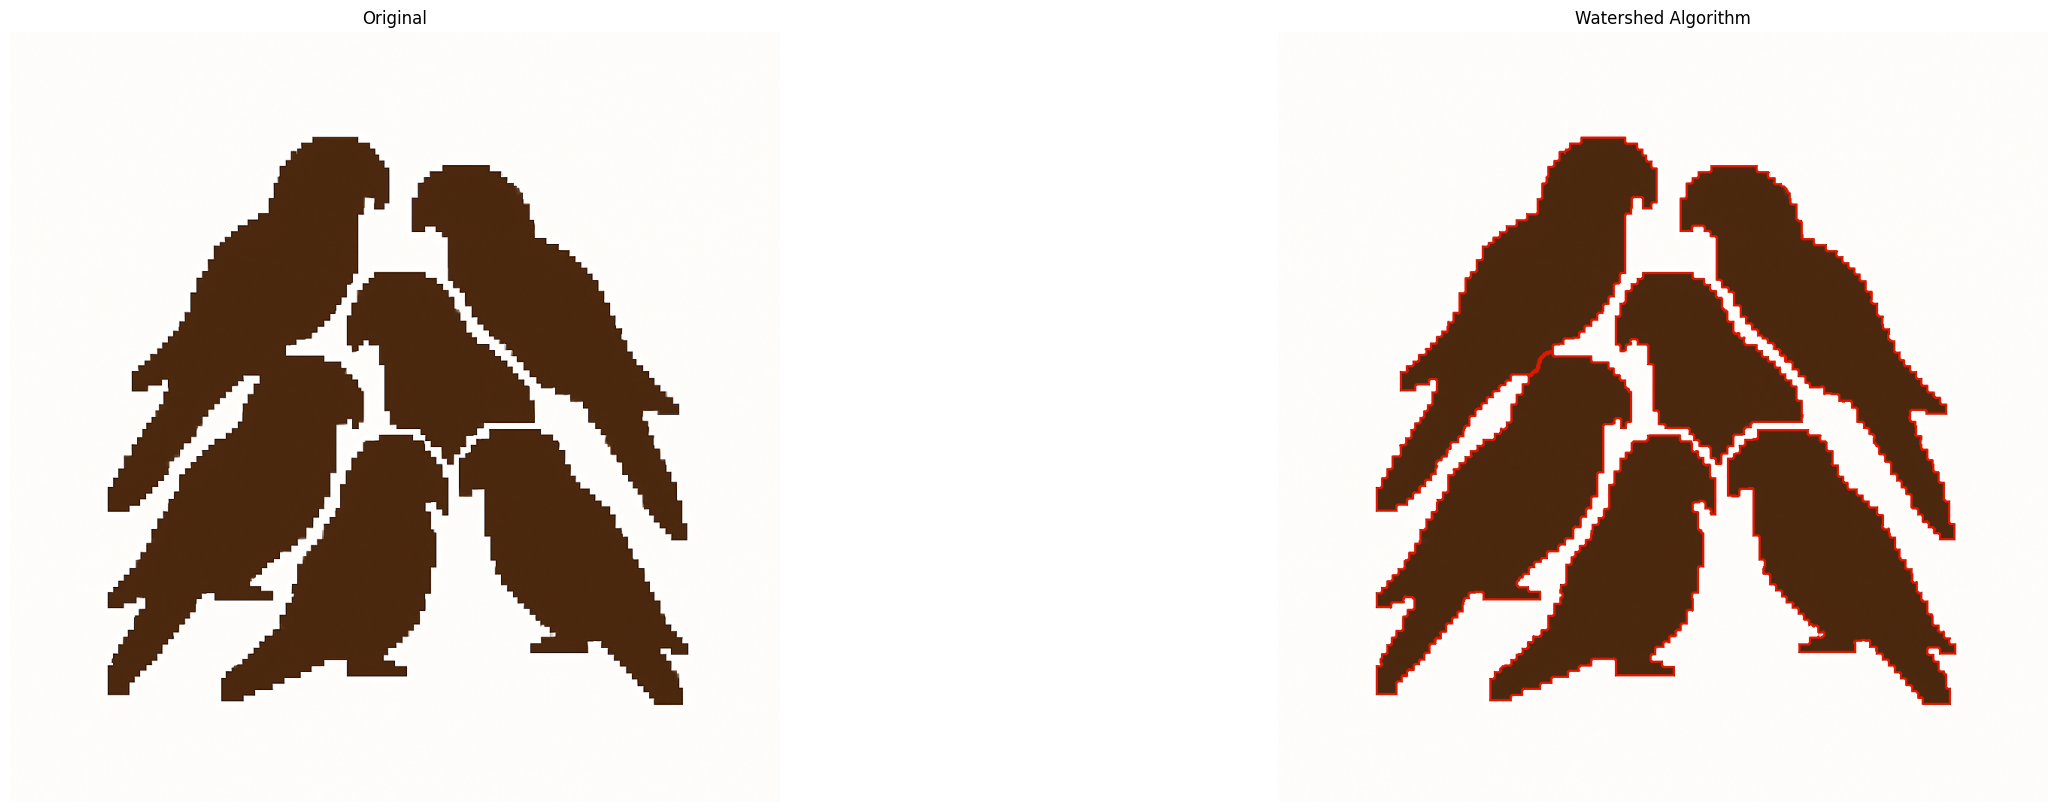

In [5]:
# Reading the sample image
original_img = cv2.imdecode(image_bytes_watershed, cv2.IMREAD_COLOR)
img = cv2.imdecode(image_bytes_watershed, cv2.IMREAD_COLOR)
g_image = cv2.imdecode(image_bytes_watershed, cv2.IMREAD_GRAYSCALE)

# Image pre-processing

# Thresholding the image, converting it to an intensity space
ret, thresh = cv2.threshold(g_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Cleaning up any artifacting in the image
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
refined = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Our sure background. This will inform the algorithm where not to place markers (water)
sure_bg = cv2.dilate(refined, kernel, iterations=3)

# Distance transform. For every foreground pixel, this computes euclidean distance to nearest background pixel.
dist = cv2.distanceTransform(refined, cv2.DIST_L2, 5)

# Foreground Area. Shrinks the foreground objects to create sure internal markers of each valley.
ret, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)

# Unknown area. This are makes up pixels that are background AND not part of the shrunken foreground markers.
# They are ambiguous, and marking them unknown allows the watershed algorithm to decide on what they are later. 
unknown = cv2.subtract(sure_bg, sure_fg)

# Labeling
# Scans the sure foreground, assigning unique integers to each connected blob in the binary mask.
ret, markers = cv2.connectedComponents(sure_fg)

# connectedComponents starts at 0 (background), and we already have one, so increment each marker by 1
markers += 1

# Mark the region of unknown with zero to be considered as valleys during the implementation of the algorithm.
markers[unknown == 255] = 0

# Watershed Algorithm
markers = cv2.watershed(img, markers)

labels = np.unique(markers)

parrots = []
for label in labels[2:]:

# Create a binary image in which only the area of the label is in the foreground
# And the rest of the image is in the background
    target = np.where(markers == label, 255, 0).astype(np.uint8)

  # Perform contour extraction on the created binary image
    contours, hierarchy = cv2.findContours(
        target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    parrots.append(contours[0])

# Draw the outline
watershed_img = cv2.drawContours(img, parrots, -1, color=(0, 23, 223), thickness=2)

# Color conversion for proper display
o_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
w_img = cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB)

# Creation of the MatPlotLib figure for comparison of images
plt.figure(figsize=[30,10])

plt.subplot(1, 2, 1)
plt.imshow(o_img, vmin=0, vmax=255)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(w_img, vmin=0, vmax=255)
plt.title("Watershed Algorithm")
plt.axis('off')

plt.show()

## Conclusion

In the next blog, we will be covering a variety of different techniques all of which will be concerned largely with edge detection. Additionally, within many of those techniques, we will begin to see many of the techniques we have already learned used as pre-processing steps, as we did in this blog.

In [12]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')